# Preparation of training and test scenario

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from Environment.distributed_app import *

In [2]:
def test_for_broken_pipe(queue_array):
    
    # max storage capacity
    machines = 15 * ['vm1'] + 10 * ['vm2'] + 3 * ['vm3']
    random.shuffle(machines)
    
    resources = {'vm1': [8,8],
                 'vm2': [16, 10],
                 'vm3': [32, 24]}
    
    distributed_app = DistributedApp(queue_array=queue_array,
                                    alpha=0.5,
                                    beta=0.5,
                                    machines=machines,
                                    resources=resources)

    time_per_step = distributed_app._perform_all_requests()
    time_per_step 
    return time_per_step

def save_scenario_to_txt(queue_array, file_name):
    file = "Environment/Scenarios/" + str(file_name) + ".txt"
    with open(file, "w") as output:
        for _, el in enumerate(queue_array):
            output.write(str(el)+"\n")

Training scenario - unstable workload 

Scenario - Train:  15


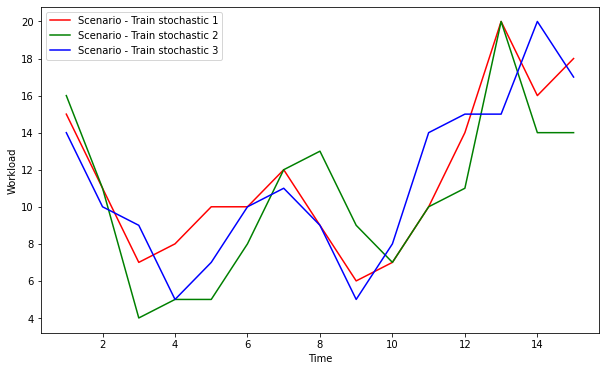

In [3]:
queue_array_train = [13, 8, 6, 5, 7, 11, 10, 12, 7, 10, 12, 14, 18, 17, 15]
queue_array_train_stochastic_1 = []
queue_array_train_stochastic_2 = []
queue_array_train_stochastic_3 = []

for _,request in enumerate(queue_array_train):
    queue_array_train_stochastic_1.append(request + random.randint(-3, 3))
    queue_array_train_stochastic_2.append(request + random.randint(-3, 3))
    queue_array_train_stochastic_3.append(request + random.randint(-3, 3))
    
    
print("Scenario - Train: ", len(queue_array_train))

time_steps = list(range(1, len(queue_array_train)+1))
workloads = pd.DataFrame({'Scenario - Train stochastic 1': queue_array_train_stochastic_1,
                          'Scenario - Train stochastic 2': queue_array_train_stochastic_2,
                          'Scenario - Train stochastic 3': queue_array_train_stochastic_3,
                          'Time': time_steps})

plt.figure(figsize=(10,6))
sns.lineplot(y='Scenario - Train stochastic 1', x='Time', data=workloads, color='red')
sns.lineplot(y='Scenario - Train stochastic 2', x='Time', data=workloads, color='green')
sns.lineplot(y='Scenario - Train stochastic 3', x='Time', data=workloads, color='blue')
plt.ylabel('Workload')
plt.legend(labels=["Scenario - Train stochastic 1",
                   "Scenario - Train stochastic 2", 
                   "Scenario - Train stochastic 3"])

In [4]:
test_for_broken_pipe(queue_array_train)

17.61426067352295

In [5]:
test_for_broken_pipe(queue_array_train_stochastic_1)

19.694772481918335

In [6]:
test_for_broken_pipe(queue_array_train_stochastic_2)

21.078075408935547

In [7]:
test_for_broken_pipe(queue_array_train_stochastic_3)

18.568104028701782

In [8]:
save_scenario_to_txt(queue_array_train, "train_scenario")

Testing scenarios

In [9]:
# scenario 1 - increasing workload, 
queue_array_1 = [1, 2, 4, 6, 4, 7, 9, 10, 14, 12, 16, 17, 19, 20, 18]

print("Scenario 1: ", len(queue_array_1))

# scenario 2 - unstable workload, 
queue_array_2 = [10, 12, 15, 14, 18, 19, 15, 13, 8, 6, 3, 7, 10, 12, 11]

print("Scenario 2: ", len(queue_array_2))

# scenario 3 - descresing workload
queue_array_3 = [18, 20, 19, 19, 16, 14, 10, 9, 12, 10, 7, 5, 3, 4, 1]

print("Scenario 3: ", len(queue_array_3))

Scenario 1:  15
Scenario 2:  15
Scenario 3:  15


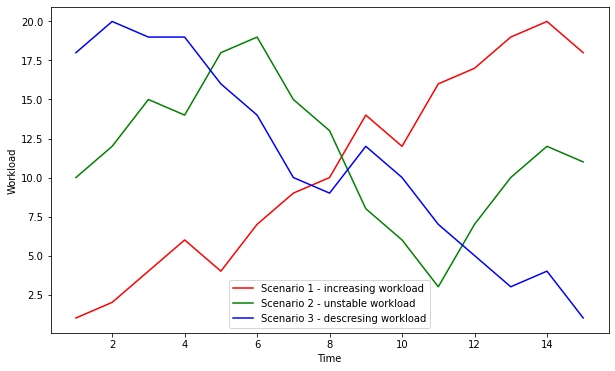

In [10]:
time_steps = list(range(1, len(queue_array_1)+1))
workloads = pd.DataFrame({'Scenario 1': queue_array_1,
                          'Scenario 2': queue_array_2,
                          'Scenario 3': queue_array_3,
                          'Time': time_steps})


plt.figure(figsize=(10,6))
sns.lineplot(y='Scenario 1', x='Time', data=workloads, color='red')
sns.lineplot(y='Scenario 2', x='Time', data=workloads, color='green')
sns.lineplot(y='Scenario 3', x='Time', data=workloads, color='blue')
plt.ylabel('Workload')
plt.legend(labels=["Scenario 1 - increasing workload",
                   "Scenario 2 - unstable workload", 
                   "Scenario 3 - descresing workload"])


Broken pipe test on multiprocessing for each scenario

In [11]:
test_for_broken_pipe(queue_array_1)

1.967238426208496

In [12]:
test_for_broken_pipe(queue_array_2)

13.75660228729248

In [13]:
test_for_broken_pipe(queue_array_3)

23.748943328857422

In [14]:
save_scenario_to_txt(queue_array_1, "test_scenario_1")
save_scenario_to_txt(queue_array_2, "test_scenario_2")
save_scenario_to_txt(queue_array_3, "test_scenario_3")